In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
competitor_df = pd.read_csv("../data/competitorpricingdata.csv")
customer_behavior_df = pd.read_csv("../data/dailycustomerbehavior.csv")
sales_df = pd.read_csv("../data/tidesalesdata.csv")
inventory_df = pd.read_csv("../data/tidewarehouseinventorysim.csv")

In [3]:
len(sales_df)

1095

In [4]:
sales_df.columns

Index(['TransactionDate', 'MRP', 'NoPromoPrice', 'SellingPrice', 'UnitsSold'], dtype='object')

In [5]:
sales_df.describe()

,MRP,NoPromoPrice,SellingPrice,UnitsSold
count,1095.000000,1095.000000,1095.000000,1095.000000
mean,108.615571,90.084082,88.796027,8.626484
std,6.173907,5.002975,6.257023,4.606473
min,99.000000,71.740000,66.000000,0.000000
25%,103.950000,86.585000,85.100000,5.000000
50%,110.190000,90.050000,89.270000,8.000000
75%,115.700000,93.500000,93.045000,11.000000
max,115.700000,104.160000,104.160000,34.000000


#### No null values

In [6]:
sales_df.isnull().sum()

TransactionDate    0
MRP                0
NoPromoPrice       0
SellingPrice       0
UnitsSold          0
dtype: int64

In [7]:
sales_df['TransactionDate'] = pd.to_datetime(sales_df['TransactionDate'], format='%d-%m-%Y')

In [8]:
sales_df.head()

,TransactionDate,MRP,NoPromoPrice,SellingPrice,UnitsSold
0,2021-01-01,99.0,97.95,97.95,12
1,2021-01-02,99.0,85.09,85.09,10
2,2021-01-03,99.0,92.93,92.93,4
3,2021-01-04,99.0,90.24,90.24,7
4,2021-01-05,99.0,92.67,92.67,12


#### Selling price distribution
Looking at this, we can say, Nirma is our main competitor

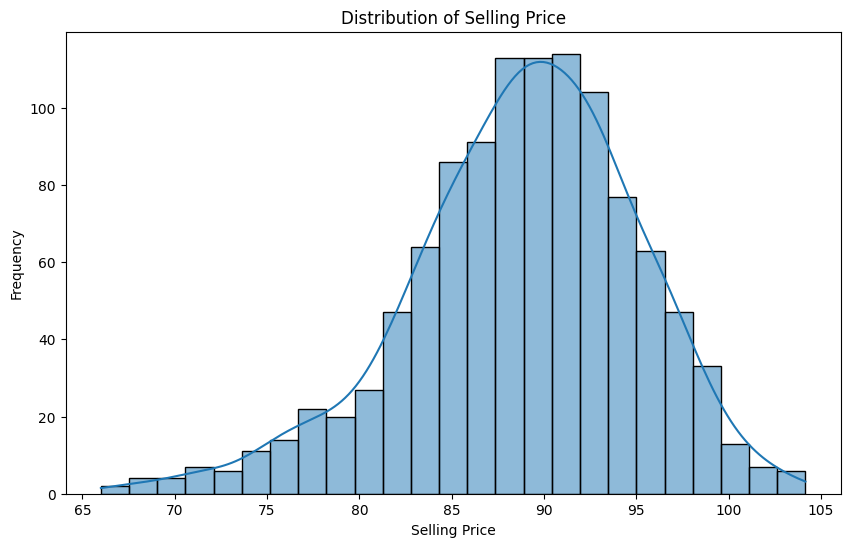

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(sales_df['SellingPrice'], kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

#### Seasonality of UnitsSold

In [ ]:
# Group the data by year and month, then mean the units sold
annual_monthly_sales = sales_df.groupby(['Year', 'Month'])['UnitsSold'].mean().reset_index()

# Find the month with the maximum units sold for each year
max_units_sold_monthly = annual_monthly_sales.loc[annual_monthly_sales.groupby('Year')['UnitsSold'].idxmax()]
# Find the month with the minimum units sold for each year
min_units_sold_monthly = annual_monthly_sales.loc[annual_monthly_sales.groupby('Year')['UnitsSold'].idxmin()]

# Combine the results
max_min_units_sold_monthly = pd.concat([max_units_sold_monthly, min_units_sold_monthly], keys=['Max', 'Min']).reset_index(level=0).rename(columns={'level_0': 'Type'})
print(max_min_units_sold_monthly)

   Type  Year  Month  UnitsSold
5   Max  2021      6  10.600000
20  Max  2022      9   9.766667
31  Max  2023      8  11.000000
3   Min  2021      4   7.266667
13  Min  2022      2   6.214286
35  Min  2023     12   6.903226


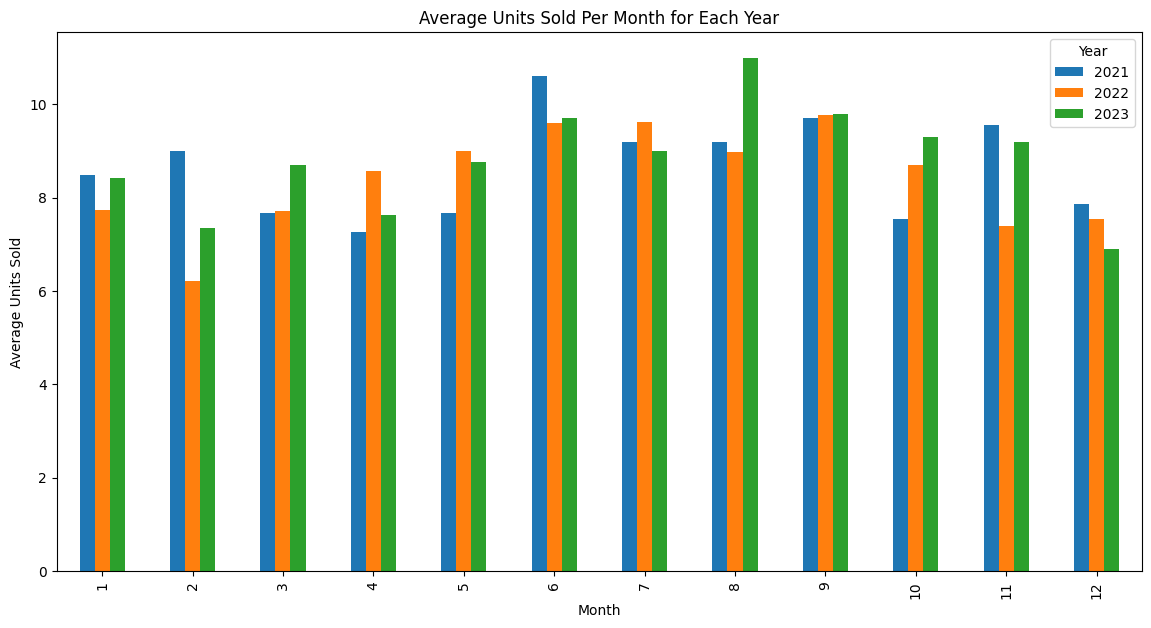

In [19]:
# Extract month and year from the 'Date' column
sales_df['Month'] = sales_df['TransactionDate'].dt.month
sales_df['Year'] = sales_df['TransactionDate'].dt.year

# Group the data by month and year
monthly_sales = sales_df.groupby(["Year", "Month"])["UnitsSold"].mean().unstack(level=0)

# Plotting the data
monthly_sales.plot(kind='bar', figsize=(14, 7))
plt.title('Average Units Sold Per Month for Each Year')
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.legend(title='Year')
plt.show()

In [54]:
# Calculate the overall average units sold per month across all years
overall_avg_units_sold = annual_monthly_sales.groupby('Month')['UnitsSold'].mean()
print("\nOverall average units sold per month across all years:")
print(overall_avg_units_sold)


Overall average units sold per month across all years:
Month
1     8.215054
2     7.523810
3     8.032258
4     7.822222
5     8.483871
6     9.966667
7     9.268817
8     9.720430
9     9.755556
10    8.516129
11    8.722222
12    7.440860
Name: UnitsSold, dtype: float64


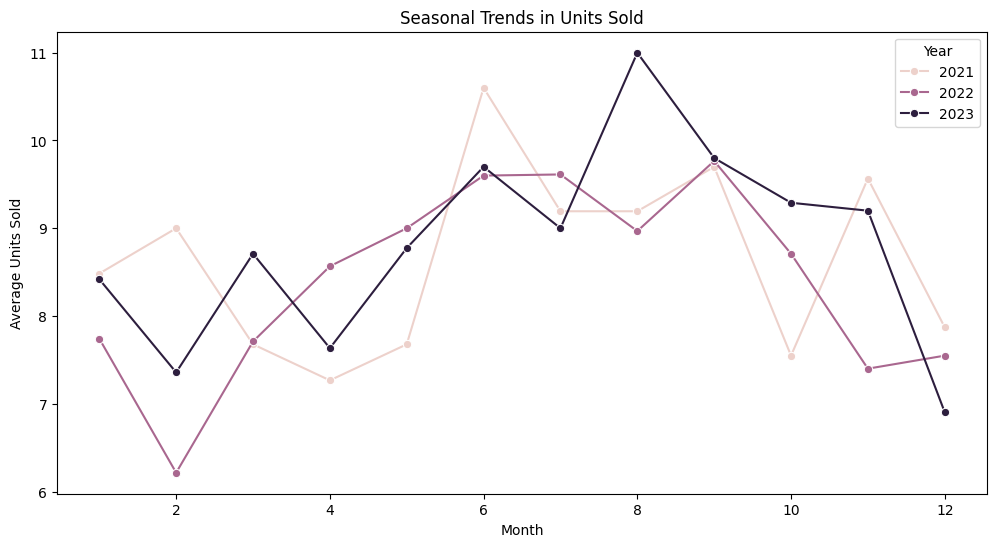

In [53]:
# Identify any seasonal trends or patterns
plt.figure(figsize=(12, 6))
sns.lineplot(data=annual_monthly_sales, x='Month', y='UnitsSold', hue='Year', marker='o')
plt.title('Seasonal Trends in Units Sold')
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.legend(title='Year')
plt.show()

#### SellingPrice vs UnitsSold
80-100 sellingprice is our golden spot

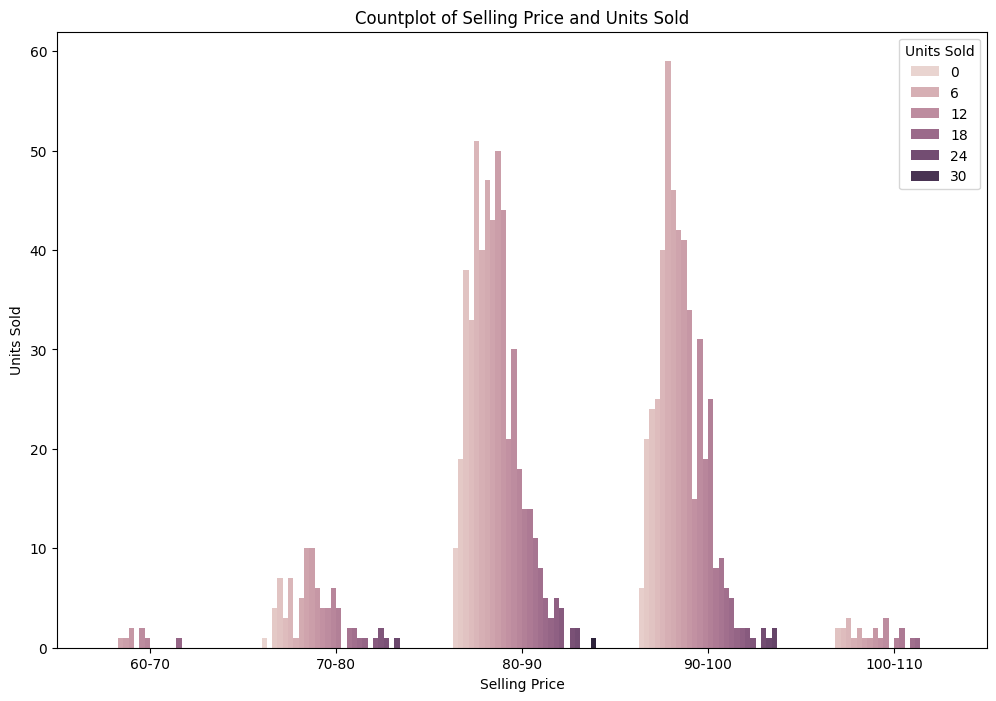

In [50]:
# Create bins for SellingPrice
bins = [60, 70, 80, 90, 100, 110]
labels = ['60-70', '70-80', '80-90', '90-100', '100-110']
sales_df['PriceRange'] = pd.cut(sales_df['SellingPrice'], bins=bins, labels=labels)

plt.figure(figsize=(12, 8))
sns.countplot(x='PriceRange', hue='UnitsSold', data=sales_df)
plt.title('Countplot of Selling Price and Units Sold')
plt.xlabel('Selling Price')
plt.ylabel('Units Sold')
plt.legend(title='Units Sold')
plt.show()